In [5]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:


def normalize_W(W):
    W = W.astype(float)
    W = W + W.T
    np.fill_diagonal(W, 0)
    min_val = W.min()
    max_val = W.max()
    if max_val - min_val < 1e-6:
        return np.zeros_like(W)
    W_norm = (W - min_val) / (max_val - min_val)
    return W_norm

def preprocess_features_simple(X, disease_type):

    # 确保没有负值
    np.clip(X, 0, None, out=X)
    
    # X= np.log1p(X)  # 使用 log1p 处理大范围数据
    
    # --- 1. 对原始病例数据进行 Min-Max 归一化到 [0, 1] ---
    max_val = X.max()
    if max_val > 0:
        X_norm = X / max_val
    else:
        X_norm = X # 全部是0的情况
        
    # --- 2. 准备并拼接静态特征 ---
    T, N = X.shape[1], X.shape[2]
    disease_feature = np.full((1, T, N, 1), disease_type)
    
    # 拼接成双通道输入: [归一化病例, 疾病类型]
    X_processed = np.concatenate([
        X_norm,
        disease_feature
    ], axis=-1)
    
    return X_processed # 最终 shape: (1, T, N, 2)

def process_single_file(file_path, output_dir, map_index):
    """
    处理单个 JSON 文件并生成对应的 .npy 文件。
    """
    print(f"Processing {file_path.name} ...")
    
    place_name = file_path.name.replace("COVIDin", "").replace(".json", "")
    target_path = output_dir / place_name
    target_path.mkdir(exist_ok=True)

    with open(file_path, "r", encoding='utf-8') as f:
        data = json.load(f)

    nodes = data["node"]
    N = len(nodes)
    if N < 2:
        print(f"  Skipping: Too few nodes ({N})")
        return None

    # --- 【核心修改 2】: 读取并转换时间索引 ---
    time_stamps = data["time"]
    date_index = pd.to_datetime(time_stamps)

    # --- 处理邻接矩阵 A/W (保持不变) ---
    G = np.array(data["G"])
    flow = np.array(data["flow"])
    W_static = np.zeros((N, N))
    for i in range(len(G)):
        u, v = G[i]
        W_static[u, v] = flow[i]
    W_norm = normalize_W(W_static)
    np.save(target_path / "A.npy", W_norm)

    # --- 处理特征矩阵 X ---
    case = np.array(data["case"])
    T = case.shape[0]
    X = case.reshape(1, T, N, 1)
    
    # 将真实的日期索引传递给预处理函数
    disease_type = 0
    X_processed = preprocess_features_simple(X, disease_type)
    np.save(target_path / "X.npy", X_processed)

    print(f"  -> Generated: {place_name} | Nodes: {N} | Features Shape: {X_processed.shape}")
    
    return {
        "map_index": map_index,
        "map_name": place_name,
        "loc_num": N
    }, X_processed



In [ ]:
cwd = Path.cwd()
data_dir = cwd / "COVID_Network_Data"
final_dir = cwd / 'v1'

# --- 初始化 ---
final_dir.mkdir(parents=True, exist_ok=True)
if not data_dir.exists():
    print(f"Error: Input directory not found at '{data_dir}'")
    
print(f"Input Data Directory: {data_dir}")
print(f"Output Directory: {final_dir}")
print("-" * 30)

json_files = sorted(data_dir.glob("COVIDin*.json"))
map_info_list = []

# --- 循环处理文件 ---
current_map_index = 0
X_processed_list = []
for file in json_files:
    try:
        map_info, X_processed = process_single_file(file, final_dir, current_map_index)
        X_processed_list.append(X_processed)
        if map_info:
            map_info_list.append(map_info)
            current_map_index += 1
    except Exception as e:
        print(f"  !!! FAILED to process {file.name}: {e}")

        import traceback
        traceback.print_exc()


json_output_path = final_dir / "map_covid19_v1.json"
with open(json_output_path, "w", encoding='utf-8') as f:
    json.dump(map_info_list, f, indent=4, ensure_ascii=False)

print("-" * 30)
print("Processing complete!")
print(f"Summary info saved to: {json_output_path}")

Input Data Directory: /home/zjy/project/AnyEpi/data/covid19_v2/COVID_Network_Data
Output Directory: /home/zjy/project/AnyEpi/data/covid19_v2/v5
------------------------------
Processing COVIDinAlabama.json ...
  -> Generated: Alabama | Nodes: 67 | Features Shape: (1, 163, 67, 2)
Processing COVIDinAlaska.json ...
  -> Generated: Alaska | Nodes: 31 | Features Shape: (1, 163, 31, 2)
Processing COVIDinArizona.json ...
  -> Generated: Arizona | Nodes: 15 | Features Shape: (1, 163, 15, 2)
Processing COVIDinArkansas.json ...
  -> Generated: Arkansas | Nodes: 75 | Features Shape: (1, 163, 75, 2)
Processing COVIDinCalifornia.json ...
  -> Generated: California | Nodes: 58 | Features Shape: (1, 163, 58, 2)
Processing COVIDinColorado.json ...
  -> Generated: Colorado | Nodes: 64 | Features Shape: (1, 163, 64, 2)
Processing COVIDinConnecticut.json ...
  -> Generated: Connecticut | Nodes: 8 | Features Shape: (1, 163, 8, 2)
Processing COVIDinDelaware.json ...
  -> Generated: Delaware | Nodes: 3 | Fe

Traceback (most recent call last):
  File "/tmp/ipykernel_2623199/3556808286.py", line 22, in <module>
    map_info, X_processed = process_single_file(file, final_dir, current_map_index)
    ^^^^^^^^^^^^^^^^^^^^^
TypeError: cannot unpack non-iterable NoneType object


  -> Generated: Missouri | Nodes: 115 | Features Shape: (1, 163, 115, 2)
Processing COVIDinMontana.json ...
  -> Generated: Montana | Nodes: 56 | Features Shape: (1, 163, 56, 2)
Processing COVIDinNebraska.json ...
  -> Generated: Nebraska | Nodes: 93 | Features Shape: (1, 163, 93, 2)
Processing COVIDinNevada.json ...
  -> Generated: Nevada | Nodes: 17 | Features Shape: (1, 163, 17, 2)
Processing COVIDinNewHampshire.json ...
  -> Generated: NewHampshire | Nodes: 10 | Features Shape: (1, 163, 10, 2)
Processing COVIDinNewJersey.json ...
  -> Generated: NewJersey | Nodes: 21 | Features Shape: (1, 163, 21, 2)
Processing COVIDinNewMexico.json ...
  -> Generated: NewMexico | Nodes: 33 | Features Shape: (1, 163, 33, 2)
Processing COVIDinNewYork.json ...
  -> Generated: NewYork | Nodes: 62 | Features Shape: (1, 163, 62, 2)
Processing COVIDinNorthCarolina.json ...
  -> Generated: NorthCarolina | Nodes: 100 | Features Shape: (1, 163, 100, 2)
Processing COVIDinNorthDakota.json ...
  -> Generated: 

正在绘制轨迹的热力图...
infection_trajectory shape:(163, 31, 1)


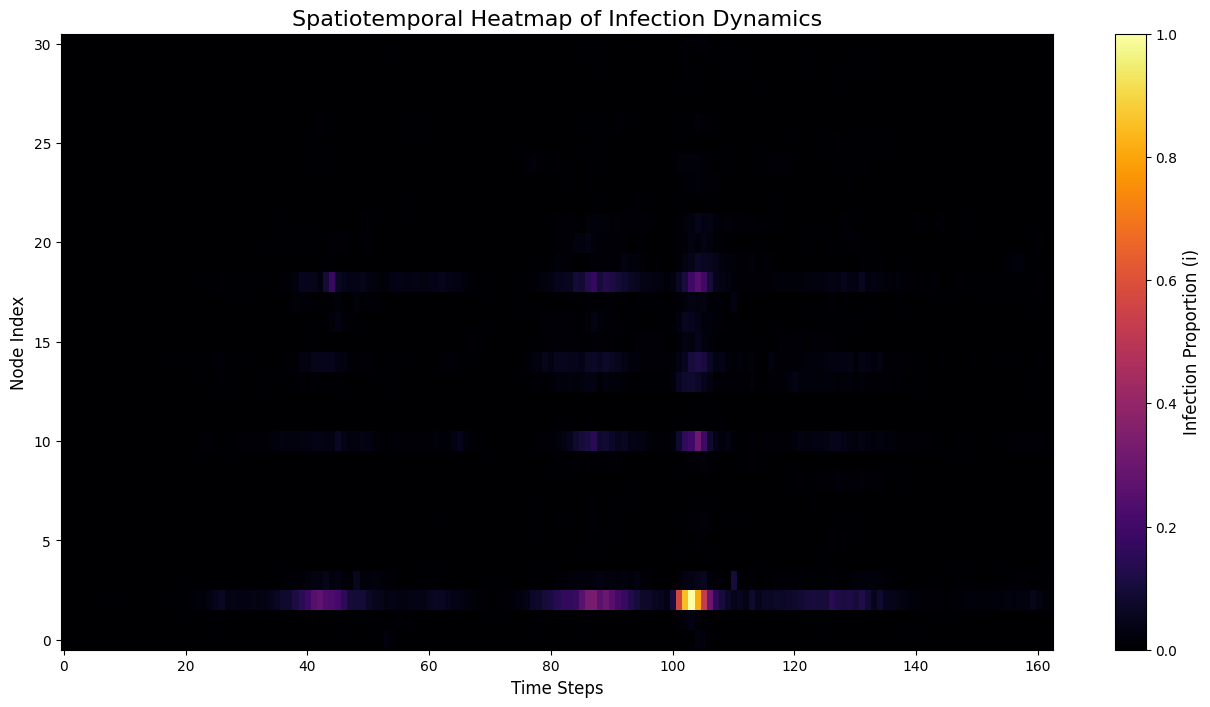

In [8]:
from matplotlib import pyplot as plt

print("正在绘制轨迹的热力图...")
index = 1
# place_name = name_list[index]
infection_trajectory = X_processed_list[index][0,:,:,0:1]
# infection_trajectory = transform_to_sparse(infection_trajectory)
# 首先，去掉最后一个维度 (特征维度)
print(f"infection_trajectory shape:{infection_trajectory.shape}")
data_for_heatmap = np.squeeze(infection_trajectory, axis=-1)
# 然后，转置数据，使得 Y 轴是节点，X 轴是时间
data_for_heatmap = data_for_heatmap.T  # 现在形状是 (n, steps)

# 创建图表
fig, ax = plt.subplots(figsize=(16, 8))

# 使用 imshow 绘制热力图
# cmap: colormap，选择一个合适的颜色映射，如 'viridis', 'plasma', 'inferno', 'Reds'
# aspect='auto': 允许图像的 x 和 y 轴有不同的缩放比例，让图像填满整个区域
# origin='lower': 将 y 轴的 0 点放在左下角，符合常规
im = ax.imshow(data_for_heatmap, cmap='inferno', aspect='auto', origin='lower')

# 添加一个颜色条 (colorbar) 来解释颜色代表的数值
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Infection Proportion (i)', fontsize=12)

# 设置图表的标题和坐标轴标签
ax.set_title('Spatiotemporal Heatmap of Infection Dynamics', fontsize=16)
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Node Index', fontsize=12)

plt.show()